# Archetype analysis on Harmony data: comparing cell cycle regressed Harmony data to see if any archetypes are dependent on cell cycle signatures

In [1]:
import scanpy as sc
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os.path as op
import sys
sys.path.insert(1, "/Users/smgroves/Documents/GitHub/multiome-analysis/archetype-plasticity-notebooks/")
from py_pcha_patched import PCHA
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist


In [2]:
adata = sc.read_h5ad('../../data/combined/adata_02_filtered.h5ad')

In [3]:
x_harmony = pd.read_csv('./ParetoTI/x_harmony2.csv', index_col = 0)

In [4]:
adata.obsm['X_pca'].shape

(8908, 50)

In [5]:
x_harmony = x_harmony.T
harmony_indices = []
for i, r in adata.obs.iterrows():
    adata_label = i.split(':')[1][:-4]+"-" + i.split("-")[1][1]
    if adata_label in x_harmony.index:
        harmony_indices.append(adata_label)
        
x_harmony = x_harmony.loc[harmony_indices]
adata.obsm['X_harmony2'] = np.array(x_harmony)

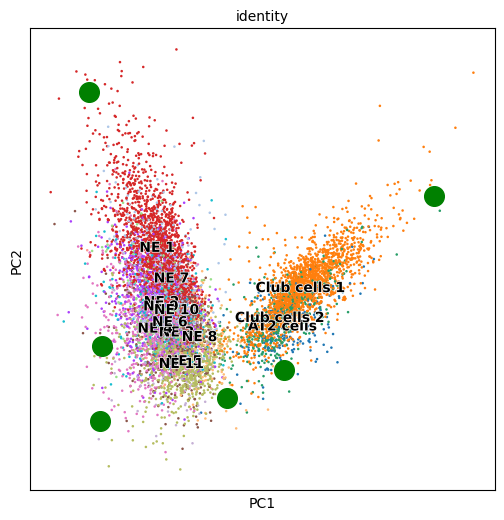

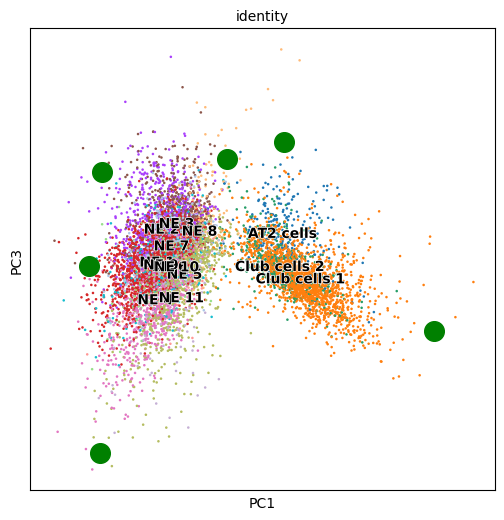

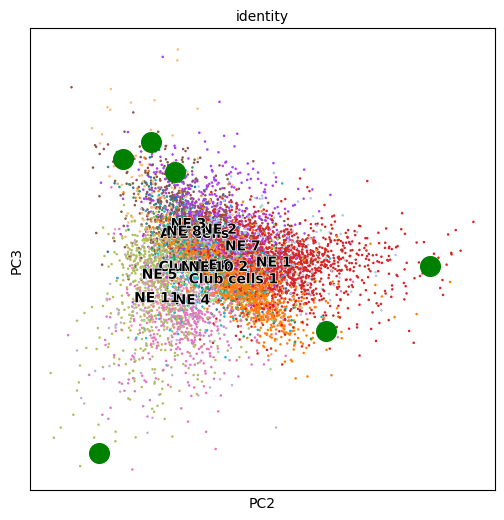

In [16]:
XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'][:,0:7].T, noc=6, delta=0)
XC = np.array(XC)
for components in ['1,2','1,3','2,3']:
    scv.pl.scatter(adata, color = 'identity', basis = 'harmony2', components=components, show=False, figsize= (6,6), frameon=True)
    comp = components.split(',')
    plt.scatter(XC[int(comp[0])-1], XC[int(comp[1])-1], color = 'green', s = 200)
    plt.xlabel("PC"+comp[0])
    plt.ylabel("PC"+comp[1])

    plt.show()

In [17]:
S_df = pd.DataFrame(S.T)
print(S_df.shape)

(8908, 6)


In [18]:
S_df.index = adata.obs_names
S_df.columns = ['Arc_1','Arc_2','Arc_3','Arc_4','Arc_5', 'Arc_6']

In [19]:
max_arc = (S_df > .5).idxmax(axis=1)

In [20]:
for i,r in S_df.iterrows():
    if r.max() < 0.5:
        max_arc[i] = 'Generalist'

In [21]:
adata.uns['archetype_locations'] = XC

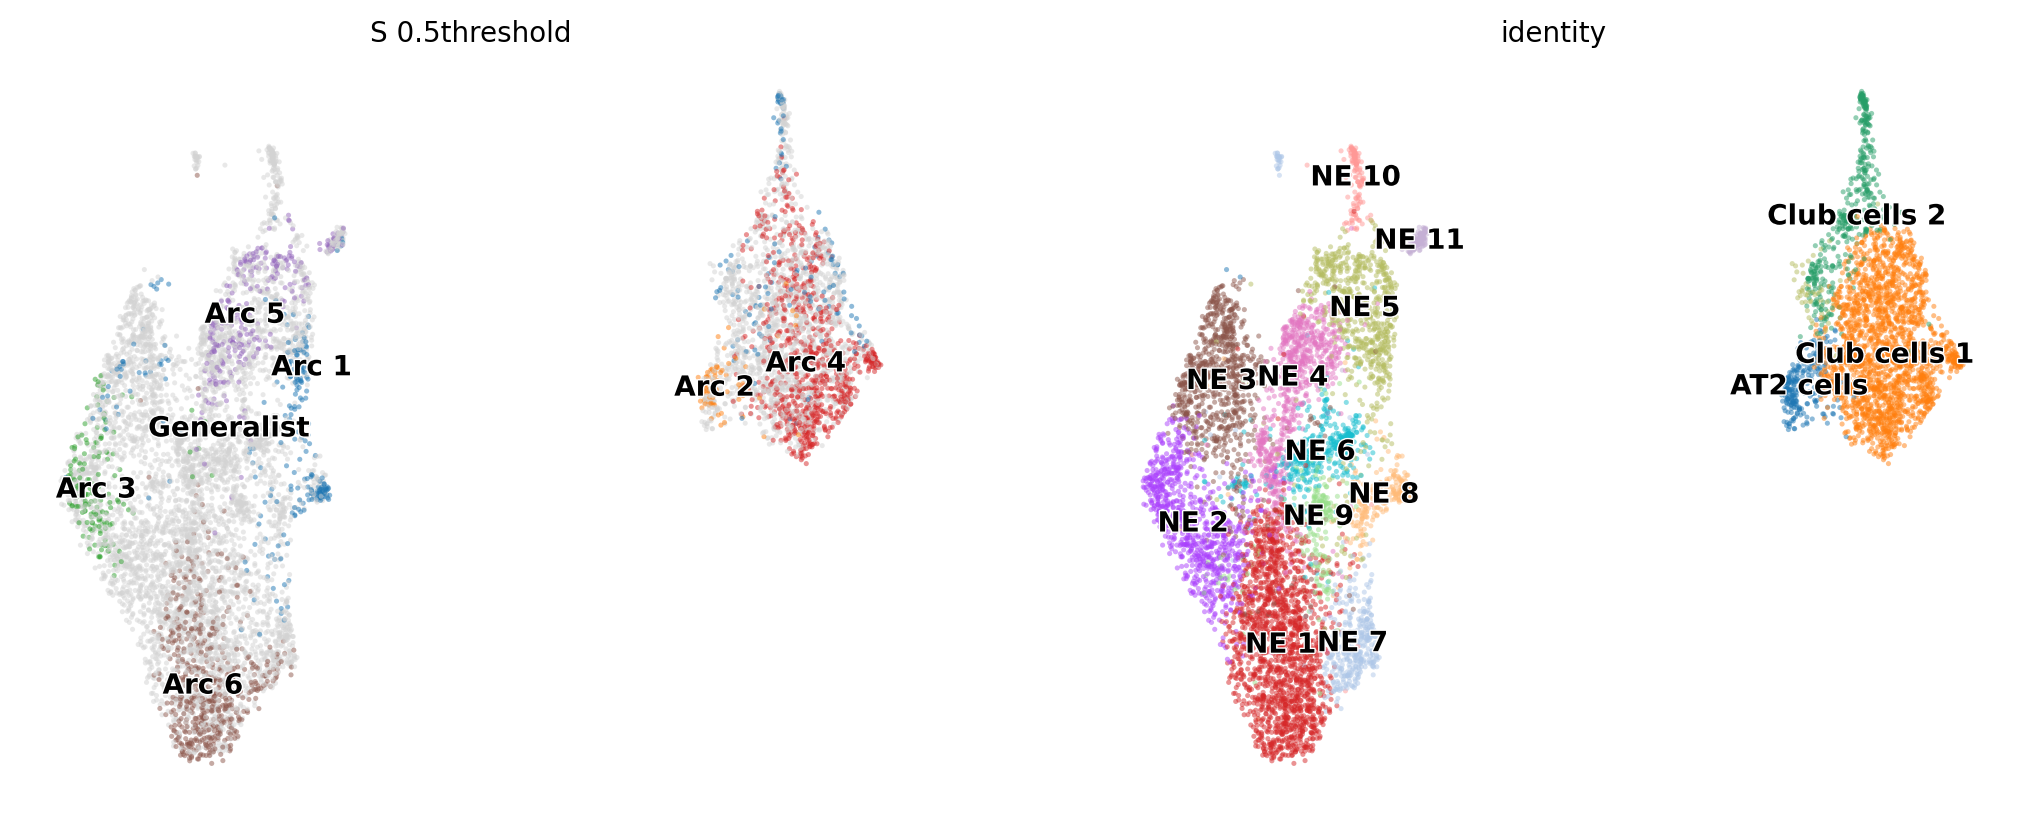

In [22]:
scv.pl.scatter(adata, basis = 'umap_wnn', color = ['S_0.5threshold','identity'], legend_loc = 'on data',dpi = 200, alpha = .5)

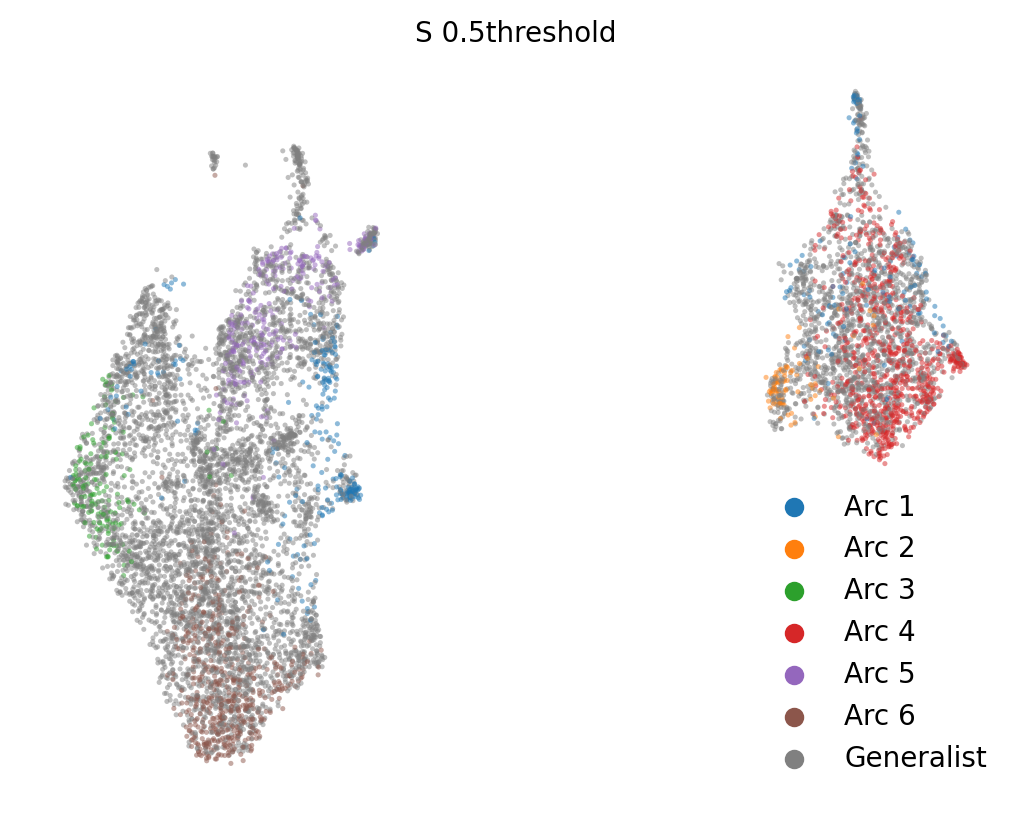

In [23]:
# Generalist is grey, Generalist NE is dark grey, Generalist nonNE is light grey
#match up archetype colors based on S_0.5threshold compared to debbie_labels in adata.obs

archetype_colors = {
    'Generalist': 'grey',
    'Arc_1': '#1f77b4', #blue
    'Arc_2': '#ff7f0e', #orange
    'Arc_3': '#2ca02c', #green
    'Arc_4': '#d62728', #red
    'Arc_5': '#9467bd', #purple
    'Arc_6': '#8c564b' #brown
}


adata.uns['S_0.5threshold_colors'] = archetype_colors

scv.pl.scatter(adata,
               basis='umap_wnn',
               color=[ 'S_0.5threshold'],
               legend_loc='best',
               dpi=200,
               alpha=.5)

## Compare to cell-cycle regressed data
Because the dimensions are not the same (Harmony was done on cell-cycle regressed data), we can't directly compare the locations of the archetypes in each space (i.e. Harmony1 != Harmony1_cc). Instead, we will run AA on the regressed data, generate new labels, and compare based on the cells that are close to each archetype.

In [39]:
x_harmony_cc = pd.read_csv('../../data/combined/CC_regressed_harmony.csv',
                           index_col=0)
x_harmony_cc.index = [i.split("-")[0] for i in x_harmony_cc.index]

In [42]:
x_harmony_cc.head()

,harmony2_1,harmony2_2,harmony2_3,harmony2_4,harmony2_5,harmony2_6,harmony2_7,harmony2_8,harmony2_9,harmony2_10,...,harmony2_41,harmony2_42,harmony2_43,harmony2_44,harmony2_45,harmony2_46,harmony2_47,harmony2_48,harmony2_49,harmony2_50
AAACAGCCACAGGGAC,1.287243,-5.892336,4.055259,2.260804,2.464314,0.546804,0.156044,-0.966303,-1.091642,-3.639063,...,1.214355,1.474410,0.729356,0.345321,-0.718271,-0.322541,-0.355616,0.238482,-0.309048,0.110991
AAACAGCCACCTATAG,1.333525,-5.976034,4.554096,-0.187156,-2.459537,-1.285468,-4.845471,-0.949256,-0.299457,0.012567,...,-1.145470,0.359684,0.024428,-2.849618,0.930093,1.036559,1.375669,0.977407,0.888659,-0.124810
AAACAGCCATGCATAT,6.309585,1.122595,1.976952,-2.974142,-0.396744,-1.021547,3.089635,0.740926,1.566080,0.096626,...,-1.274410,1.464856,-0.149636,0.429889,1.786709,-1.168131,2.454139,1.141917,0.461114,-0.681843
AAACATGCAAGGTAAC,12.399103,-5.034717,-1.748438,-0.380735,1.892400,-2.704071,-6.488831,-2.587271,-0.713746,0.663040,...,3.877366,-1.289896,-2.411819,-4.596379,1.202888,-1.412164,1.000857,-1.631550,0.874166,1.280852
AAACATGCAATGAAGC,12.475389,5.629405,4.330967,14.527054,-8.361006,1.881849,-2.017769,3.124931,-5.548654,0.505347,...,1.215463,-0.841628,0.673438,0.571520,-1.243024,-3.344799,-2.479519,-1.681912,-2.240648,-0.490933


In [79]:
#AAACAGCCACAGGGAC-2 in x_harmony_CC is gex_possorted_bam_SJSO3:AAACAGCCACAGGGACx-M1 in adata
# make harmony_cc in adata.obsm and then fill with x_harmony_cc values based on matching index or NaNs if no match
adata.obsm['X_harmony_cc'] = pd.DataFrame(index=adata.obs_names,
                                          columns=x_harmony_cc.columns)
for i, r in adata.obs.iterrows():
    adata_label = i.split(':')[1][:-4]
    if adata_label in x_harmony_cc.index:
        try:
            print(f"Matching {adata_label} in adata and x_harmony_cc")
            adata.obsm['X_harmony_cc'].loc[i] = x_harmony_cc.loc[adata_label]
        except ValueError:
            print(f"ValueError: {adata_label} not found in x_harmony_cc")
    else:
        adata.obsm['X_harmony_cc'].loc[i] = np.nan

Matching AAACCGGCAGCCTAAC in adata and x_harmony_cc
Matching AAAGCCGCACCCACCT in adata and x_harmony_cc
Matching AAACGTACAGGACCAA in adata and x_harmony_cc
Matching AAAGGACGTAACGAGG in adata and x_harmony_cc
Matching AAACATGCAATGAAGC in adata and x_harmony_cc
Matching AAACCGGCACCTCACC in adata and x_harmony_cc
Matching AAAGGAGCATCCTGAA in adata and x_harmony_cc
Matching AAAGCACCAACAGGAT in adata and x_harmony_cc
Matching AAAGGACGTTACGCGG in adata and x_harmony_cc
Matching AAACGCGCAACACCTA in adata and x_harmony_cc
Matching AAACCAACATTAGCGC in adata and x_harmony_cc
Matching AAACGCGCACTGGCTG in adata and x_harmony_cc
Matching AAACGCGCACCTGCTC in adata and x_harmony_cc
Matching AAACGTACATTGTCAG in adata and x_harmony_cc
Matching AAACCGGCAGATTCAT in adata and x_harmony_cc
Matching AAACGCGCATTCAGCA in adata and x_harmony_cc
Matching AAAGCGGGTTAACACG in adata and x_harmony_cc
Matching AAAGCAAGTGTCCAGG in adata and x_harmony_cc
Matching AAAGGACGTGCATTAG in adata and x_harmony_cc
Matching AAA

In [100]:
ev_per_arc_ = []
for i in range(2,10):
    XC, S, C, SSE, varexpl = PCHA(np.array(adata.obsm['X_harmony_cc'].dropna(), dtype=float).T, noc=i, delta=0)
    ev_per_arc_.append(varexpl)
    print(f"{i} vertices: ",varexpl)

2 vertices:  0.34914657989012976
3 vertices:  0.4090419869210542
4 vertices:  0.44428374629068673
5 vertices:  0.47271651057107333
6 vertices:  0.5041591631539964
7 vertices:  0.5305930415186886
8 vertices:  0.5511752521648094
9 vertices:  0.5671903715329942


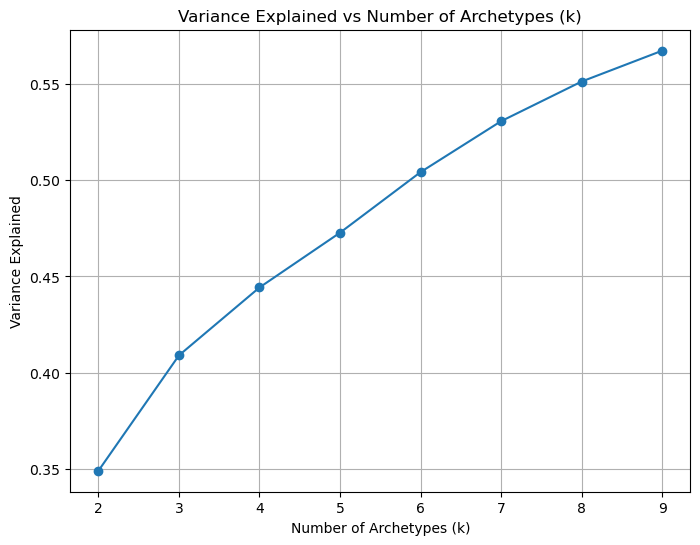

In [104]:
#plot ev_per_arc_ vs k_values
k_values = np.arange(2, 10)
plt.figure(figsize=(8, 6))
plt.plot(k_values, ev_per_arc_, marker='o')
plt.title('Variance Explained vs Number of Archetypes (k)')
plt.xlabel('Number of Archetypes (k)')
plt.ylabel('Variance Explained')
plt.xticks(k_values)
plt.grid()
plt.show()

In [ ]:
from kneed import KneeLocator

k_values = np.arange(2, 10)

kneedle = KneeLocator(
    k_values, 
    ev_per_arc_, 
    curve='concave',      # Use 'concave' if variance explained increases and levels off
    direction='increasing'  # Variance explained increases with k
)

knee = kneedle.knee
print(f"K* = {knee} archetypes (using kneed library)")


K* = None archetypes (using kneed library)


In [108]:
XC, S, C, SSE, varexpl = PCHA(np.array(adata.obsm['X_harmony_cc'].dropna(), dtype=float).T,
                              noc=6,
                              delta=0)
S_df = pd.DataFrame(S.T, index=[i for i in adata.obsm['X_harmony_cc'].dropna().index])

S_df.columns = ['Arc_1', 'Arc_2', 'Arc_3', 'Arc_4', 'Arc_5', 'Arc_6']

max_arc = (S_df > .5).idxmax(axis=1)
for i, r in S_df.iterrows():
    if r.max() < 0.5:
        max_arc[i] = 'Generalist'
adata.obs['S_0.5threshold_CC'] = max_arc
#make categorical with same order as S_0.5threshold
adata.obs['S_0.5threshold_CC'] = pd.Categorical(adata.obs['S_0.5threshold_CC'], categories=['Generalist', 'Arc_1', 'Arc_2', 'Arc_3', 'Arc_4', 'Arc_5', 'Arc_6'], ordered=True)

In [110]:
new_names_dict = {
    'Generalist': 'Generalist',
    'Arc_1': "Intermediate",
    'Arc_2': 'nonNE2',
    'Arc_3': 'Stress',
    'Arc_4': 'nonNE1',
    'Arc_5': 'Neuroendocrine1',
    'Arc_6': 'Neuroendocrine2'
}
adata.obs['S_0.5threshold_renamed'] = adata.obs['S_0.5threshold'].map(new_names_dict)

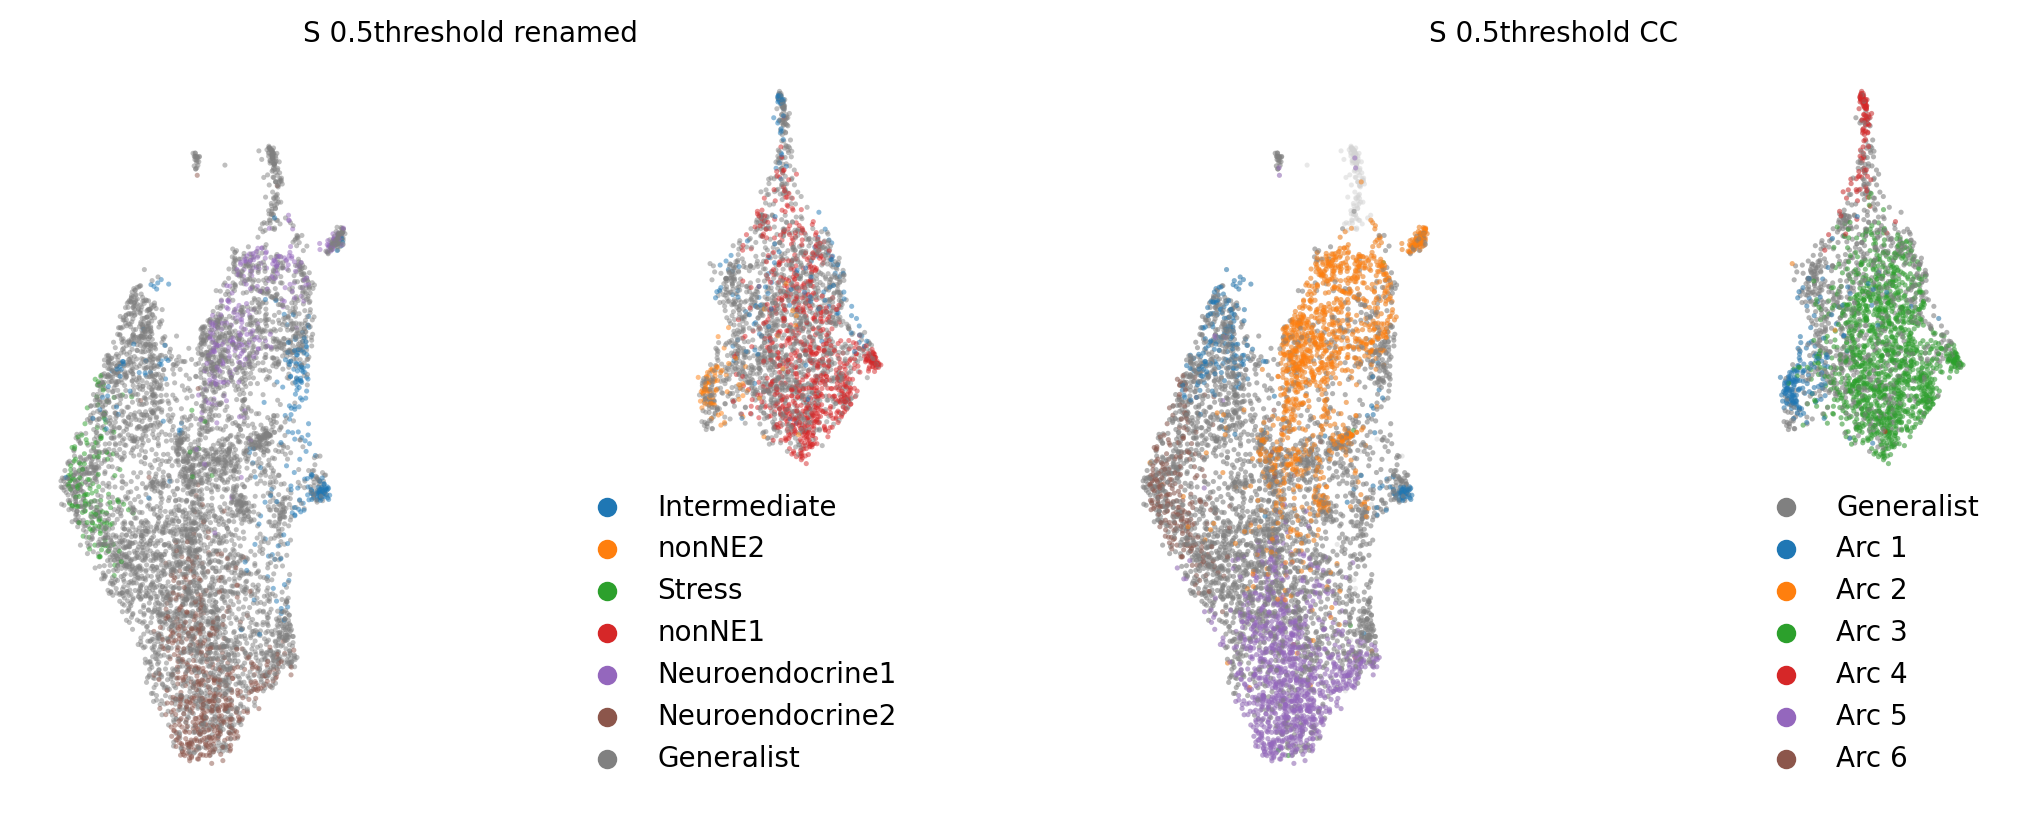

In [116]:
archetype_colors = {
    'Generalist': 'grey',
    'Arc_1': '#1f77b4', #blue
    'Arc_2': '#ff7f0e', #orange
    'Arc_3': '#2ca02c', #green
    'Arc_4': '#d62728', #red
    'Arc_5': '#9467bd', #purple
    'Arc_6': '#8c564b' #brown
}

debbie_colors = {
    'Generalist': 'grey',
    'Generalist NE': 'darkgrey',
    'Generalist nonNE': 'lightgrey',
    'Intermediate': archetype_colors['Arc_1'],
    'nonNE2': archetype_colors['Arc_2'],
    'Stress': archetype_colors['Arc_3'],
    'nonNE1': archetype_colors['Arc_4'],
    'Neuroendocrine1': archetype_colors['Arc_5'],
    'Neuroendocrine2': archetype_colors['Arc_6']
}


adata.uns['S_0.5threshold_colors'] = archetype_colors
adata.uns['S_0.5threshold_CC_colors'] = archetype_colors
adata.uns['S_0.5threshold_renamed_colors'] = debbie_colors


scv.pl.scatter(adata,
               basis='umap_wnn',
               color=[ 'S_0.5threshold_renamed','S_0.5threshold_CC'],
               legend_loc='best',
               dpi=200,
               alpha=.5)

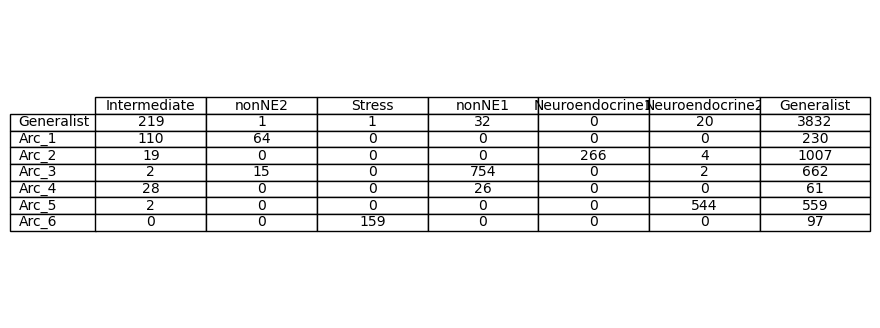

In [120]:
#save crosstab to png
from pandas.plotting import table

fig, ax = plt.subplots(figsize=(10, 4))
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ct = pd.crosstab(
    adata.obs['S_0.5threshold_CC'],
    adata.obs['S_0.5threshold_renamed'])
# Render the table
tab = table(ax, ct, loc='center', cellLoc='center')
tab.auto_set_font_size(False)
tab.set_fontsize(10)
plt.savefig('crosstab.png', dpi=200, bbox_inches='tight')


Correlation between archetypes for k=3 and k=6:
[[ 0.37009609 -0.35645062 -0.13924678 -0.08808709  0.84492776 -0.35153997]
 [ 0.37330944 -0.77080704  0.76288493 -0.47515403 -0.53378247  0.86868529]
 [-0.56157638  0.98254019 -0.69135093  0.51881821  0.03086339 -0.64661691]]
Correlation between archetypes for k=4 and k=6:
[[-0.55488873  0.98388518 -0.68952211  0.51872511  0.01512974 -0.63833875]
 [ 0.31530168 -0.28123839 -0.27050907 -0.0684367   0.89016924 -0.34726591]
 [ 0.41873577 -0.64631173  0.38925063 -0.4238557  -0.47536835  0.97332816]
 [ 0.22412998 -0.67325677  0.9985572  -0.35685427 -0.39747047  0.37479236]]
Correlation between archetypes for k=5 and k=6:
[[ 0.26765302 -0.74003714  0.77650059 -0.46588275 -0.53784352  0.86662331]
 [ 0.99607765 -0.50111663  0.20045241 -0.31164463 -0.13479489  0.25413365]
 [-0.09341424 -0.14927932 -0.23250334 -0.05132994  0.97278994 -0.45164133]
 [-0.50564689  0.99935387 -0.67470822  0.36876396 -0.02225405 -0.60244525]
 [-0.31334088  0.39096319 -0.

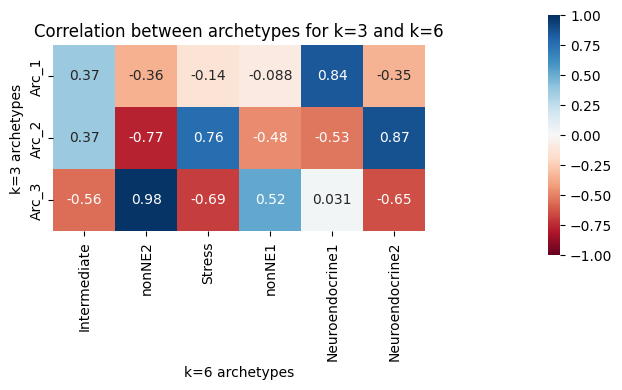

Optimal matching for k=3:
  Arc_1 (k=3) ↔ Neuroendocrine1 (k=6): corr = 0.845
  Arc_2 (k=3) ↔ Neuroendocrine2 (k=6): corr = 0.869
  Arc_3 (k=3) ↔ nonNE2 (k=6): corr = 0.983


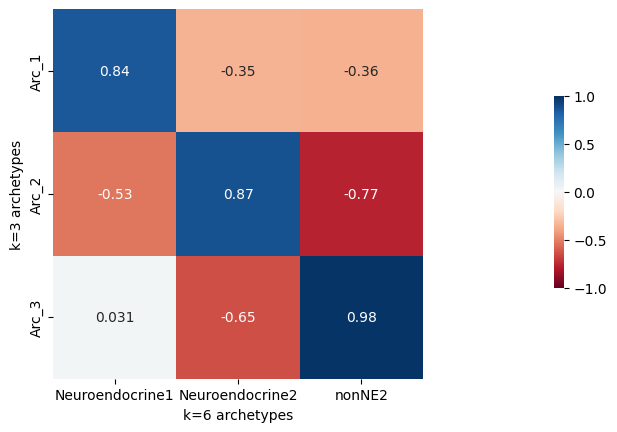

(4, 50) (6, 50)


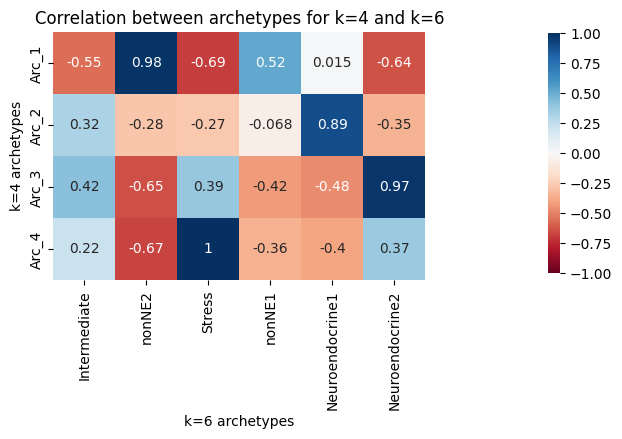

Optimal matching for k=4:
  Arc_1 (k=4) ↔ nonNE2 (k=6): corr = 0.984
  Arc_2 (k=4) ↔ Neuroendocrine1 (k=6): corr = 0.890
  Arc_3 (k=4) ↔ Neuroendocrine2 (k=6): corr = 0.973
  Arc_4 (k=4) ↔ Stress (k=6): corr = 0.999


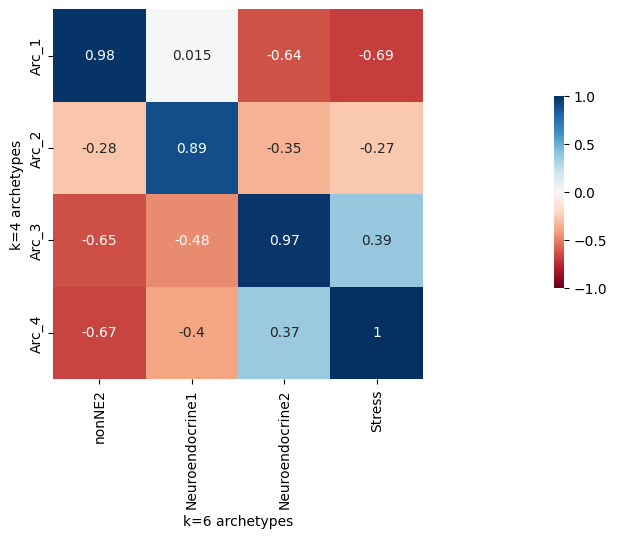

(5, 50) (6, 50)


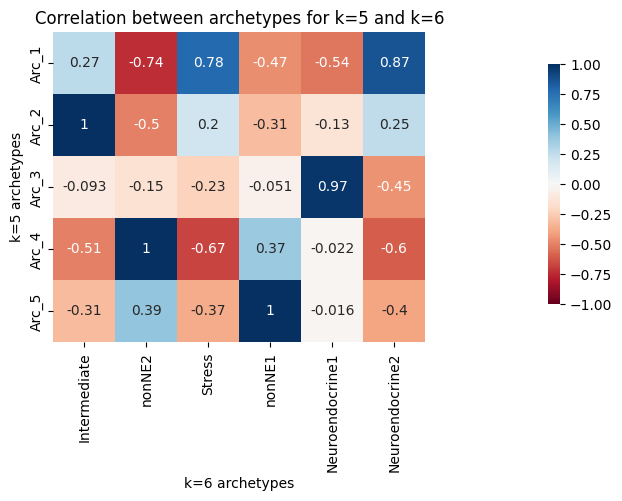

Optimal matching for k=5:
  Arc_1 (k=5) ↔ Neuroendocrine2 (k=6): corr = 0.867
  Arc_2 (k=5) ↔ Intermediate (k=6): corr = 0.996
  Arc_3 (k=5) ↔ Neuroendocrine1 (k=6): corr = 0.973
  Arc_4 (k=5) ↔ nonNE2 (k=6): corr = 0.999
  Arc_5 (k=5) ↔ nonNE1 (k=6): corr = 0.998


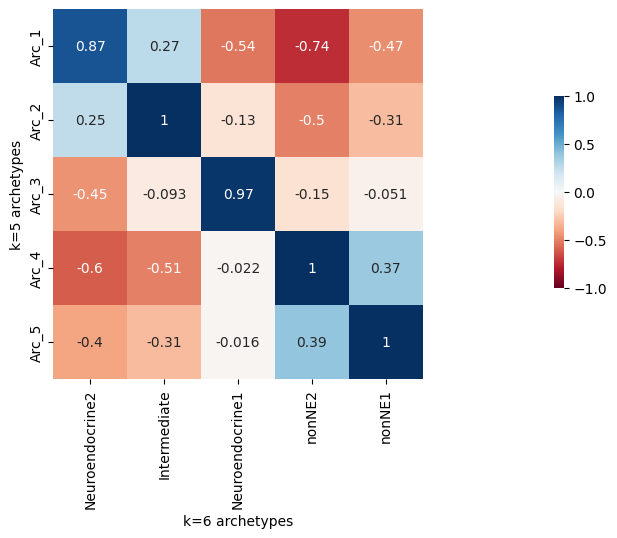

(6, 50) (6, 50)


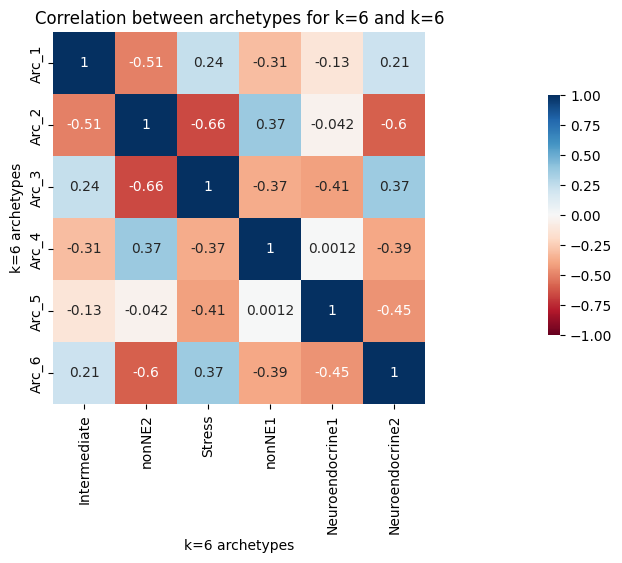

Optimal matching for k=6:
  Arc_1 (k=6) ↔ Intermediate (k=6): corr = 1.000
  Arc_2 (k=6) ↔ nonNE2 (k=6): corr = 1.000
  Arc_3 (k=6) ↔ Stress (k=6): corr = 1.000
  Arc_4 (k=6) ↔ nonNE1 (k=6): corr = 1.000
  Arc_5 (k=6) ↔ Neuroendocrine1 (k=6): corr = 1.000
  Arc_6 (k=6) ↔ Neuroendocrine2 (k=6): corr = 1.000


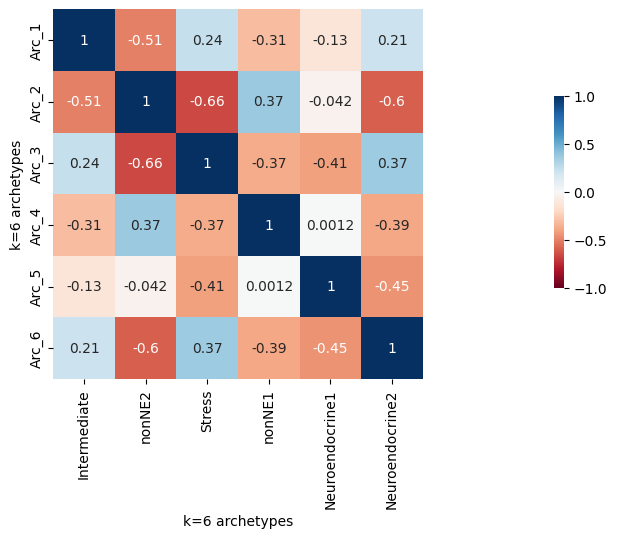

(7, 50) (6, 50)


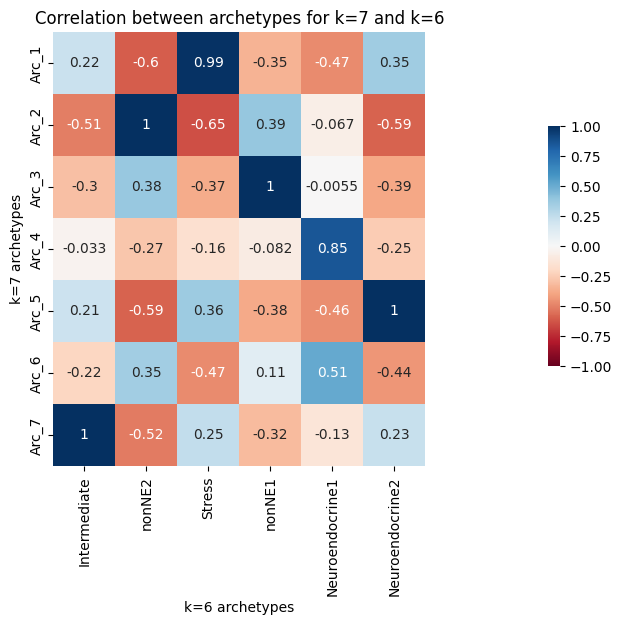

Optimal matching for k=7:
  Arc_1 (k=7) ↔ Stress (k=6): corr = 0.991
  Arc_2 (k=7) ↔ nonNE2 (k=6): corr = 0.996
  Arc_3 (k=7) ↔ nonNE1 (k=6): corr = 0.998
  Arc_4 (k=7) ↔ Neuroendocrine1 (k=6): corr = 0.853
  Arc_5 (k=7) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_7 (k=7) ↔ Intermediate (k=6): corr = 0.999


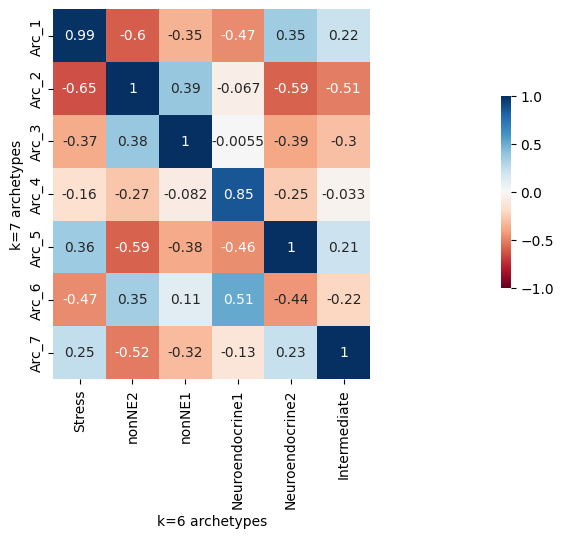

(8, 50) (6, 50)


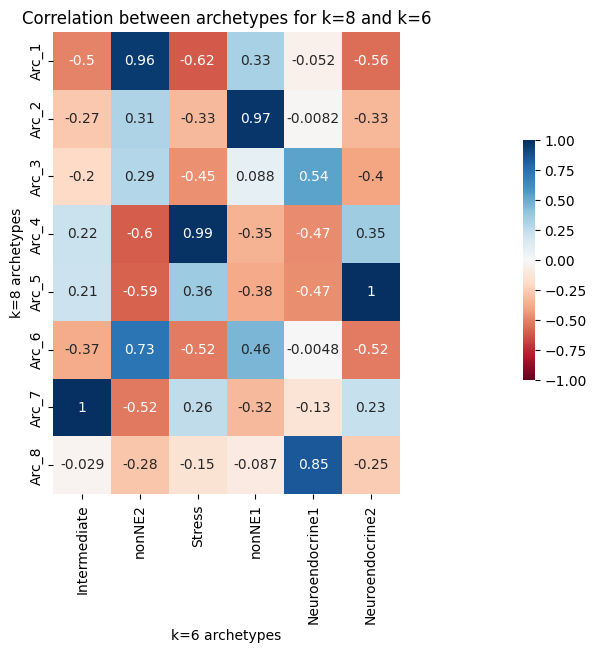

Optimal matching for k=8:
  Arc_1 (k=8) ↔ nonNE2 (k=6): corr = 0.958
  Arc_2 (k=8) ↔ nonNE1 (k=6): corr = 0.971
  Arc_4 (k=8) ↔ Stress (k=6): corr = 0.991
  Arc_5 (k=8) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_7 (k=8) ↔ Intermediate (k=6): corr = 0.999
  Arc_8 (k=8) ↔ Neuroendocrine1 (k=6): corr = 0.849


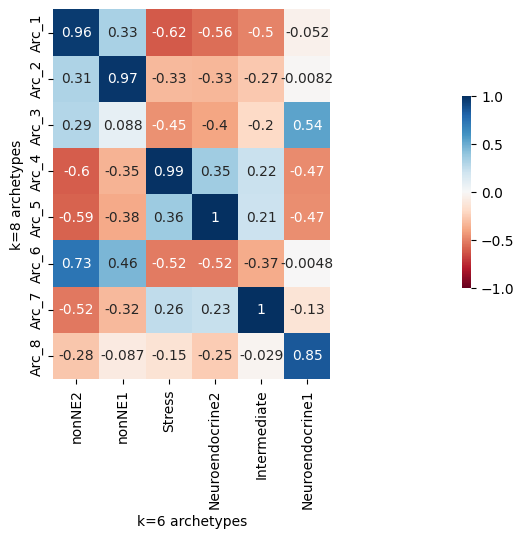

In [109]:
from scipy.optimize import linear_sum_assignment

#correlation between archetypes across different k
for i in range(3, 9):
    print(f"Correlation between archetypes for k={i} and k=6:")
    print(np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:])

arc_6_labels = ['Intermediate', 'nonNE2', 'Stress', 'nonNE1', 'Neuroendocrine1', 'Neuroendocrine2']
for i in range(3, 9):
    plt.figure(figsize=(6,6))
    plt.title(f"Correlation between archetypes for k={i} and k=6")
    #show numbers on heatmap
    print(adata.uns[f'XC_{i}'].shape, adata.uns[f'XC_6'].shape)
    corr_mat = np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:]
    sns.heatmap(corr_mat, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_full_10PCs.png')
    plt.show()
    plt.close() 
    #reorder axes in corr_mat so that highest correlation in on diagonal

    # Find optimal matching (maximize correlation = minimize negative correlation)
    row_ind, col_ind = linear_sum_assignment(-corr_mat)

    # Reorder columns to align with rows
    corr_mat_reordered = corr_mat[:, col_ind]

    # Also reorder the labels
    arc_6_labels_reordered = [arc_6_labels[j] for j in col_ind]

    print(f"Optimal matching for k={i}:")
    for r, c in zip(row_ind, col_ind):
        print(f"  Arc_{r+1} (k={i}) ↔ {arc_6_labels[c]} (k=6): corr = {corr_mat[r, c]:.3f}")

    sns.heatmap(corr_mat_reordered, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels_reordered, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_matched_10PCs.png')
    plt.show()
        

In [111]:
#calculate 6 archetypes with different random seeds and see how consistent they are
for seed in [42, 0, 1, 2, 3, 4]:
    np.random.seed(seed)
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'].T, noc=6, delta=0.1)
    XC = np.array(XC)
    adata.uns[f'XC_6_seed_{seed}'] = XC.T
    print(f"Correlation between archetypes for k=6 with seed {seed} and seed 42:")
    print(np.corrcoef(adata.uns[f'XC_6_seed_{seed}'], adata.uns[f'XC_6_seed_42'])[:6, 6:])

Correlation between archetypes for k=6 with seed 42 and seed 42:
[[ 1.00000000e+00  2.40189327e-01 -5.06624278e-01 -3.09630700e-01
   2.11067644e-01 -1.27900512e-01]
 [ 2.40189327e-01  1.00000000e+00 -6.60891329e-01 -3.72730122e-01
   3.66645627e-01 -4.10833212e-01]
 [-5.06624278e-01 -6.60891329e-01  1.00000000e+00  3.74765839e-01
  -6.01275698e-01 -4.29466463e-02]
 [-3.09630700e-01 -3.72730122e-01  3.74765839e-01  1.00000000e+00
  -3.86752754e-01  8.66750719e-04]
 [ 2.11067644e-01  3.66645627e-01 -6.01275698e-01 -3.86752754e-01
   1.00000000e+00 -4.47181333e-01]
 [-1.27900512e-01 -4.10833212e-01 -4.29466463e-02  8.66750719e-04
  -4.47181333e-01  1.00000000e+00]]
Correlation between archetypes for k=6 with seed 0 and seed 42:
[[ 0.9999999   0.24019239 -0.50661162 -0.30961585  0.21106152 -0.12791373]
 [ 0.24015676  0.9999996  -0.66112976 -0.37281247  0.36643727 -0.41028009]
 [-0.50655248 -0.66081332  0.99999986  0.37484868 -0.60108294 -0.04329128]
 [-0.30950882 -0.37259628  0.3744525   

## Try different numbers of archetypes to see if intermediate state is still found
Analysis using top 7 harmony components

In [ ]:


adata_pca_df = pd.DataFrame(adata.obsm['X_harmony2'], index = adata.obs_names)

for i in range(3, 8):
# for i in [7]:
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'][:,:7].T, noc=i, delta=0.1)
    print(S.shape)
    # S matrix labeling
    print(f"Processing k={i} archetypes, EV explained: {varexpl}")
    S_df = pd.DataFrame(S.T)
    S_df.index = adata.obs_names
    adata.obsm[f'S_{i}'] = S_df
    max_arc = (S_df > .5).idxmax(axis=1)
    for j,r in S_df.iterrows():
        if r.max() < 0.5:
            max_arc[j] = 'Generalist'
    adata.obs[f'S_0.5threshold_{i}'] = max_arc
    # distance to archetype
    print(f"Calculating distances to archetypes for k={i}...")
    XC_df = pd.DataFrame(XC)
    adata.uns[f'XC_{i}'] = XC_df.T
    #append to bottom of adata_pca_df and then compute distances to archetypes on pca space
    adata_full_df = pd.concat([adata_pca_df, XC_df.T], axis = 0)
    pdx = squareform(pdist(adata_full_df, metric='euclidean')) # compute distances on pca
    pdx_df = pd.DataFrame(pdx, index=adata_full_df.index, columns=adata_full_df.index)
    pdx_df = pdx_df.loc[XC_df.columns].drop(XC_df.columns, axis = 1)
    adata.obsm[f'arc_distance_{i}'] = pdx_df.T

        

(7, 8908)
Processing k=7 archetypes, EV explained: 0.9842653785012689
Calculating distances to archetypes for k=7...


Correlation between archetypes for k=3 and k=6:
[[ 0.03335714  0.28002979 -0.65621821  0.9823671  -0.4016801  -0.62725157]
 [ 0.66806629  0.35451878 -0.32590106 -0.45891017 -0.23912771  0.40647072]
 [-0.48022669 -0.53148482  0.8998587  -0.71222164  0.56276173  0.39853448]]
Correlation between archetypes for k=4 and k=6:
[[-0.05469086  0.2332368  -0.60310923  0.9931671  -0.41406254 -0.56630139]
 [-0.19300912 -0.23538625  0.48744802 -0.63655175 -0.07537947  0.90329905]
 [-0.47732594 -0.50707261  0.84704196 -0.64976782  0.68687676  0.21665716]
 [ 0.84560077  0.52430933 -0.65213261 -0.01902279 -0.25356756 -0.21851222]]
Correlation between archetypes for k=5 and k=6:
[[-0.35864095 -0.31543599  0.9979363  -0.57383513  0.18624992  0.14084807]
 [ 0.83618663  0.67963645 -0.47874932 -0.01834649 -0.52218066 -0.2538912 ]
 [-0.29050715 -0.50722476  0.21494239 -0.48872518  0.97129337  0.23202205]
 [-0.22522112 -0.32528153  0.21780122 -0.54824035  0.11622043  0.99907736]
 [-0.07192412  0.19638316 -0.

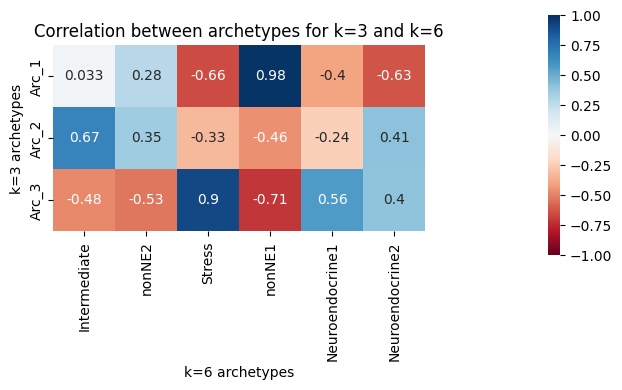

Optimal matching for k=3:
  Arc_1 (k=3) ↔ nonNE1 (k=6): corr = 0.982
  Arc_2 (k=3) ↔ Intermediate (k=6): corr = 0.668
  Arc_3 (k=3) ↔ Stress (k=6): corr = 0.900


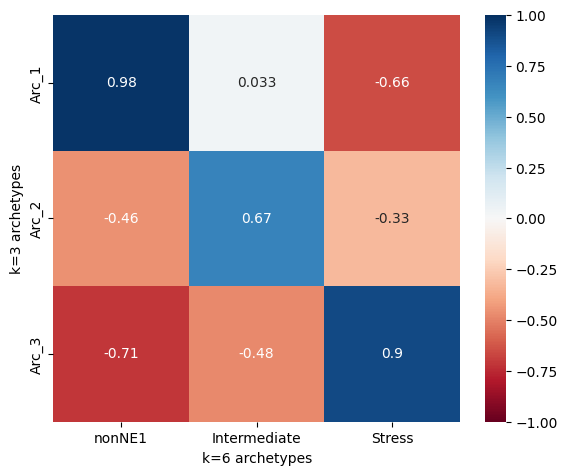

(4, 7) (6, 7)


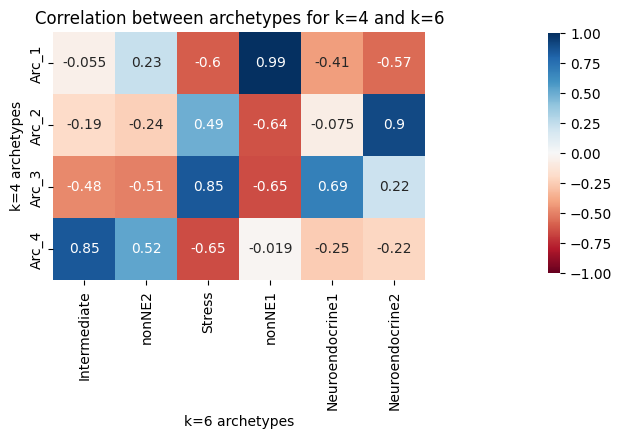

Optimal matching for k=4:
  Arc_1 (k=4) ↔ nonNE1 (k=6): corr = 0.993
  Arc_2 (k=4) ↔ Neuroendocrine2 (k=6): corr = 0.903
  Arc_3 (k=4) ↔ Stress (k=6): corr = 0.847
  Arc_4 (k=4) ↔ Intermediate (k=6): corr = 0.846


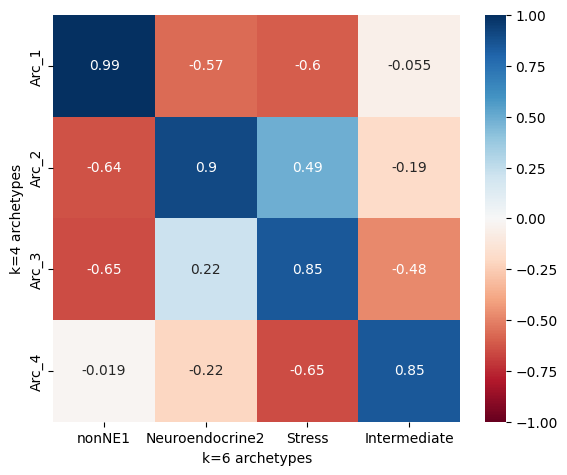

(5, 7) (6, 7)


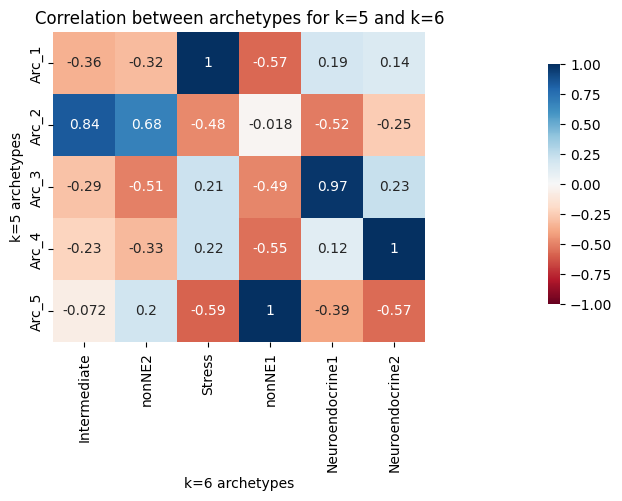

Optimal matching for k=5:
  Arc_1 (k=5) ↔ Stress (k=6): corr = 0.998
  Arc_2 (k=5) ↔ Intermediate (k=6): corr = 0.836
  Arc_3 (k=5) ↔ Neuroendocrine1 (k=6): corr = 0.971
  Arc_4 (k=5) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_5 (k=5) ↔ nonNE1 (k=6): corr = 0.996


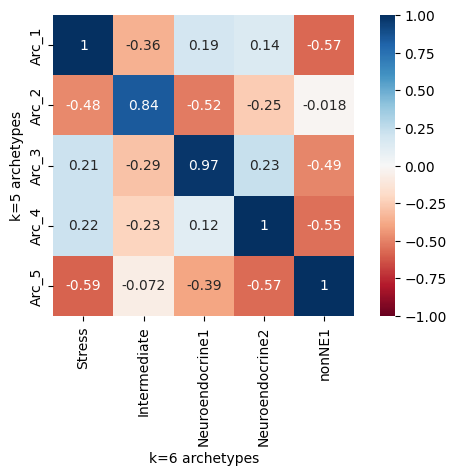

(6, 7) (6, 7)


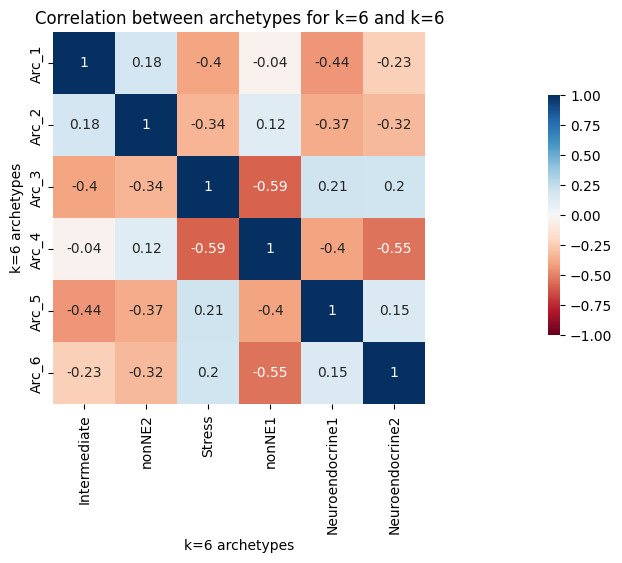

Optimal matching for k=6:
  Arc_1 (k=6) ↔ Intermediate (k=6): corr = 1.000
  Arc_2 (k=6) ↔ nonNE2 (k=6): corr = 1.000
  Arc_3 (k=6) ↔ Stress (k=6): corr = 1.000
  Arc_4 (k=6) ↔ nonNE1 (k=6): corr = 1.000
  Arc_5 (k=6) ↔ Neuroendocrine1 (k=6): corr = 1.000
  Arc_6 (k=6) ↔ Neuroendocrine2 (k=6): corr = 1.000


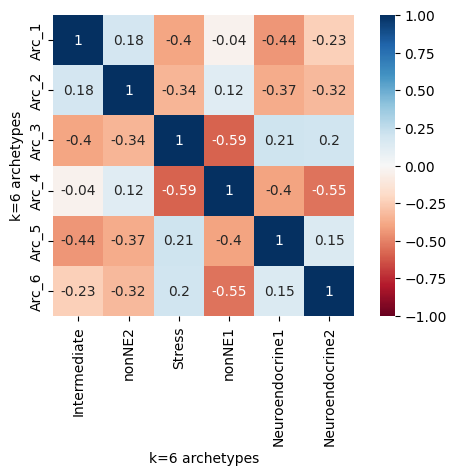

(7, 7) (6, 7)


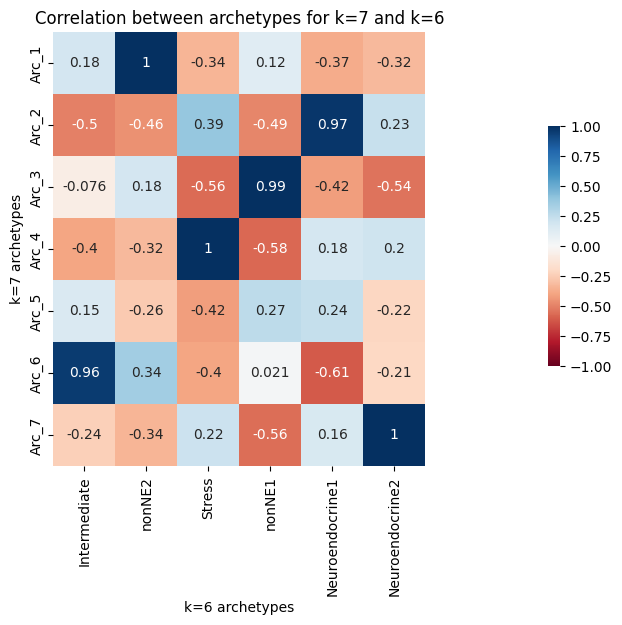

Optimal matching for k=7:
  Arc_1 (k=7) ↔ nonNE2 (k=6): corr = 1.000
  Arc_2 (k=7) ↔ Neuroendocrine1 (k=6): corr = 0.974
  Arc_3 (k=7) ↔ nonNE1 (k=6): corr = 0.994
  Arc_4 (k=7) ↔ Stress (k=6): corr = 0.999
  Arc_6 (k=7) ↔ Intermediate (k=6): corr = 0.955
  Arc_7 (k=7) ↔ Neuroendocrine2 (k=6): corr = 1.000


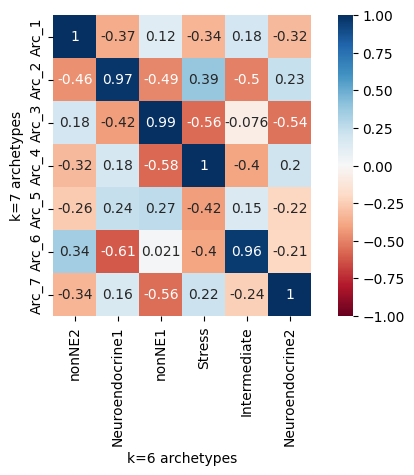

In [21]:

from scipy.optimize import linear_sum_assignment

#correlation between archetypes across different k
for i in range(3, 8):
    print(f"Correlation between archetypes for k={i} and k=6:")
    print(np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:])

arc_6_labels = ['Intermediate', 'nonNE2', 'Stress', 'nonNE1', 'Neuroendocrine1', 'Neuroendocrine2']
for i in range(3, 8):
    plt.figure(figsize=(6,6))
    plt.title(f"Correlation between archetypes for k={i} and k=6")
    #show numbers on heatmap
    print(adata.uns[f'XC_{i}'].shape, adata.uns[f'XC_6'].shape)
    corr_mat = np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:]
    sns.heatmap(corr_mat, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_full_7PCs.png')

    plt.show()
    plt.close() 
    #reorder axes in corr_mat so that highest correlation in on diagonal

    # Find optimal matching (maximize correlation = minimize negative correlation)
    row_ind, col_ind = linear_sum_assignment(-corr_mat)

    # Reorder columns to align with rows
    corr_mat_reordered = corr_mat[:, col_ind]

    # Also reorder the labels
    arc_6_labels_reordered = [arc_6_labels[j] for j in col_ind]

    print(f"Optimal matching for k={i}:")
    for r, c in zip(row_ind, col_ind):
        print(f"  Arc_{r+1} (k={i}) ↔ {arc_6_labels[c]} (k=6): corr = {corr_mat[r, c]:.3f}")

    sns.heatmap(corr_mat_reordered, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels_reordered, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.tight_layout()
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_matched_7PCs.png')
    plt.show()